<a href="https://colab.research.google.com/github/Tipusultan199/kkk/blob/main/Phase1C_Colab_Synchronizer_Debug_READY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1C — Tri-Modal Synchronizer Debug Notebook

This notebook keeps the **main synchronization logic** from your original `Phase-1-C-Synchronizer.ipynb`, but organizes it cell-by-cell for Colab.

It prints checks after each major step:

1. Load and prepare timestamp column
2. Sort and remove duplicate timestamps
3. Detect EEG, EMG, and eye-tracking columns
4. Estimate sampling frequency
5. Estimate EMG↔EEG and EEG↔ET lag
6. Build a fixed 250 Hz time grid
7. Apply lag shifts, anti-alias filtering, and interpolation
8. Export synchronized CSV and JSON lag log
9. Verify saved files and plot synchronized EEG/EMG/ET on the same time grid


In [3]:
# ============================================================
# CELL 1 — Upload the Phase 1B/cleaned CSV and set configuration
# This cell uploads one CSV to Colab and defines synchronization settings.
# ============================================================

from __future__ import annotations
import os, glob, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import signal
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
from IPython.display import display

# Upload one CSV file, for example: 063_T24.csv or 063_T24_phase1B_train_schema_checked.csv
from google.colab import files
uploaded = files.upload()

if len(uploaded) == 0:
    raise FileNotFoundError("No CSV file was uploaded.")

INPUT_CSV = Path(list(uploaded.keys())[0])
OUTPUT_DIR = Path("/content/phase1C_synchronized_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Original Phase 1C CONFIG
# -------------------------
GRID_MODE    = "fixed"     # "fixed" (target grid) or "native"
FIXED_HZ     = 250         # target fs
SPAN_MODE    = "all"       # "all" (union) or "overlap"
GRID_STEP_MS = 1000.0 / FIXED_HZ  # 4 ms

# Cross-corr params (for lag estimation)
CROSS_FS       = 1000
XCORR_MIN_SEC  = 6.0
XCORR_WIN_SEC  = 12.0
NWIN_BINS      = 5
NWIN_SELECT    = 3
MIN_ACCEPTED   = 2

# Filters (for feature extraction during lag estimation)
EEG_BP      = (1.0, 40.0)
EMG_ENV_LP  = 10.0
ET_VEL_BP   = (0.5, 10.0)
BP_ORDER    = 3

# Anti-aliasing (for downsampling to FIXED_HZ)
AA_ENABLE   = True
AA_ORDER    = 8
AA_MARGIN   = 0.45
AA_TOL      = 1.05
AA_DISCRETE_COLS = {
    'ET_ValidityLeftEye','ET_ValidityRightEye','ET_Blink','ET_Fixation',
    'ET_Worn','EventSource.3'
}

# Guards/fallbacks
LAG_MIN_PEAK_RATIO        = 4.0
EMGEEG_LAG_ABS_REJECT_MS  = 150.0
FALLBACK_MAX_ABS_MS       = 50.0
ET_XCORR_MIN_PR           = 8.0
ET_XCORR_MAX_ABS_MS       = 60.0
ET_REVERT_MARGIN          = 0.007

# Robust-bounding knobs
EMGEEG_LAG_SEARCH_MAX_MS = 200.0
BOUNDARY_HIT_FRACTION    = 0.90
TAPER_WINDOWS            = True
NAN_INTERP_FOR_CORR      = True
AGREE_TOL_MS             = 30.0

# Output formatting
FLOAT_DECIMALS        = 4
KEEP_LSL_TIMESTAMP    = False
WRITE_JSON_LOG        = True
SCALE_EMG_TO_uV       = False

# Optional soft prior
EMG_EEG_PRIOR_MS = -28.0
PRIOR_STRENGTH   = 0.6

warnings.filterwarnings("ignore")

print("Uploaded input CSV:", INPUT_CSV)
print("Output directory  :", OUTPUT_DIR)
print("GRID_MODE         :", GRID_MODE)
print("FIXED_HZ          :", FIXED_HZ)
print("SPAN_MODE         :", SPAN_MODE)


Saving 063_T24 (1).csv to 063_T24 (1) (1).csv
Uploaded input CSV: 063_T24 (1) (1).csv
Output directory  : /content/phase1C_synchronized_output
GRID_MODE         : fixed
FIXED_HZ          : 250
SPAN_MODE         : all


In [4]:
# ============================================================
# CELL 2 — Define validation printer
# This cell prints PASS/FAIL after every synchronization step.
# ============================================================

def print_step_result(step_name, passed, details=""):
    if passed:
        print(f"✅ CLEANING APPLIED CORRECTLY — {step_name}")
    else:
        print(f"❌ CLEANING NOT APPLIED CORRECTLY — {step_name}")
    if details:
        print(details)


In [5]:
# ============================================================
# CELL 3 — Original Phase 1C helper functions
# This cell keeps the main synchronizer helper logic from your original code.
# ============================================================

def load_and_prepare(path: str | Path) -> pd.DataFrame:
    """Respect existing Timestamp_seconds. Sort & dedup time for monotonicity."""
    df = pd.read_csv(path, encoding="utf-8-sig")
    if 'Timestamp_seconds' in df.columns:
        df['Timestamp_seconds'] = pd.to_numeric(df['Timestamp_seconds'], errors='coerce')
    else:
        # Fallbacks only if Timestamp_seconds is missing
        ts_candidates = [
            'Timestamp', 'iMotions_Synchronization_Timestamp', 'iMotions_Synchronization_Timestamp(ms)'
        ]
        ts_col = next((c for c in ts_candidates if c in df.columns), None)
        if ts_col is not None:
            df['Timestamp_seconds'] = pd.to_numeric(df[ts_col], errors='coerce') / 1000.0
        elif 'ET_TimeSignal' in df.columns:
            v = pd.to_numeric(df['ET_TimeSignal'], errors='coerce')
            df['Timestamp_seconds'] = (v/1000.0) if v.dropna().max() > 1e4 else v.astype(float)
            warnings.warn("Using ET_TimeSignal as fallback timebase.")
        else:
            raise ValueError("No global timestamp column found.")

    df = df.sort_values('Timestamp_seconds').drop_duplicates('Timestamp_seconds')
    return df


def split_modalities(df: pd.DataFrame):
    """Exact modality selection per your schema."""
    emg_cols = [c for c in ["Ch1 EMG raw","Ch2 EMG raw","Ch3 EMG raw","Ch4 EMG raw"] if c in df.columns]
    eeg_cols = [c for c in [f"Ch{i}" for i in range(1,9)] if c in df.columns]
    et_cols  = [c for c in df.columns if c.startswith("ET_")]

    emg = df if emg_cols else df.iloc[0:0].copy()
    eeg = df if eeg_cols else df.iloc[0:0].copy()
    et  = df if et_cols  else df.iloc[0:0].copy()
    return emg, eeg, et, emg_cols, eeg_cols, et_cols


def estimate_fs(ts: np.ndarray) -> float:
    if ts is None or len(ts) < 3: return 0.0
    dt = np.diff(ts); dt = dt[(dt > 0) & (dt < 1.0)]
    if len(dt)==0: return 0.0
    return 1.0/np.median(dt)


def _butter_band(x, fs, f1, f2, order=BP_ORDER):
    try:
        ny = fs/2.0
        if 0 < f1 < f2 < ny:
            b,a = signal.butter(order, [f1/ny, f2/ny], btype='band')
            return signal.filtfilt(b,a,x)
    except Exception:
        pass
    return x


def _butter_lp(x, fs, fc, order=BP_ORDER):
    try:
        ny = fs/2.0
        if 0 < fc < ny:
            b,a = signal.butter(order, fc/ny, btype='low')
            return signal.filtfilt(b,a,x)
    except Exception:
        pass
    return x


def _interp_vec(t_src, y_src, t_grid, kind='linear'):
    m = np.isfinite(t_src) & np.isfinite(y_src)
    if m.sum() < 2: return np.full_like(t_grid, np.nan, dtype=float)
    f = interp1d(t_src[m], y_src[m], kind=kind, bounds_error=False, fill_value=np.nan)
    return f(t_grid)


def _round_to_grid_ms(lag_ms: float) -> float:
    return float(np.round(lag_ms / GRID_STEP_MS) * GRID_STEP_MS)


def _overlap_limits(t1, t2):
    return max(np.nanmin(t1), np.nanmin(t2)), min(np.nanmax(t1), np.nanmax(t2))


def _pick_energy_windows(t, x, ov_start, ov_end, n_bins=NWIN_BINS, n_select=NWIN_SELECT, win_sec=XCORR_WIN_SEC):
    if ov_end - ov_start <= win_sec + 1.0:
        return [(max(ov_start, ov_start+0.5), min(ov_end, ov_end-0.5))]
    edges = np.linspace(ov_start+0.5, ov_end-0.5, n_bins+1)
    cand = []
    for i in range(n_bins):
        a = edges[i]
        b_target = a + win_sec
        b = edges[i+1] if (edges[i+1] - a) < win_sec else b_target
        m = (t>=a) & (t<=b)
        if m.sum() < 10:
            continue
        v = np.nanvar(x[m])
        cand.append((v, a, b))
    cand.sort(key=lambda z: z[0], reverse=True)
    wins = [(a,b) for _,a,b in cand[:max(1, n_select)]]
    return wins if wins else [(ov_start+0.5, min(ov_end-0.5, ov_start+0.5+win_sec))]


def _prep_for_corr(t, x, fs, seg_start, seg_end, bp=None):
    m = (t>=seg_start) & (t<=seg_end)
    if m.sum() < 10: return None, None
    n = int((seg_end-seg_start)*fs)
    if n < 100: return None, None
    th = np.linspace(seg_start, seg_end, n, endpoint=False)
    xh = _interp_vec(t[m], x[m], th)

    if NAN_INTERP_FOR_CORR:
        idx = np.arange(len(xh))
        mm = np.isfinite(xh)
        if mm.sum() >= 2:
            f = interp1d(idx[mm], xh[mm], bounds_error=False,
                         fill_value=(xh[mm][0], xh[mm][-1]))
            xh = f(idx)
        else:
            xh = np.nan_to_num(xh)

    xh = (xh - np.nanmean(xh)) / (np.nanstd(xh) + 1e-12)
    xh = np.nan_to_num(xh)

    if bp is not None:
        xh = _butter_band(xh, fs, bp[0], bp[1])

    if TAPER_WINDOWS:
        win = np.hanning(len(xh))
        if win.max() > 0:
            xh = xh * win

    return th, xh


def _bounded_peak(lags, corr, fs, lag_max_ms):
    max_samp = int(np.floor((lag_max_ms/1000.0) * fs))
    m = (lags >= -max_samp) & (lags <= max_samp)
    if not np.any(m): return np.nan, np.nan, np.nan
    l = lags[m]; c = corr[m]

    ai = int(np.argmax(np.abs(c)))
    peak = c[ai]
    pr = float((np.abs(peak)) / (np.median(np.abs(c)) + 1e-12))

    return float(l[ai]), float(peak), pr


def _xcorr_lag(th, x1h, x2h, fs, lag_max_ms):
    corr = signal.correlate(x1h, x2h, mode='full')
    lags = signal.correlation_lags(len(x1h), len(x2h), mode='full')
    lag_samp, peak, pr = _bounded_peak(lags, corr, fs, lag_max_ms)
    if not np.isfinite(lag_samp): return np.nan, np.nan
    return (lag_samp / fs) * 1000.0, pr


def _gcc_phat_lag(x1h, x2h, fs, lag_max_ms):
    n = int(2**np.ceil(np.log2(len(x1h) + len(x2h) - 1)))
    X1 = np.fft.rfft(x1h, n=n); X2 = np.fft.rfft(x2h, n=n)
    R = X1*np.conj(X2)
    denom = np.abs(R) + 1e-12
    R /= denom
    corr = np.fft.irfft(R, n=n)
    corr = np.concatenate((corr[-(len(x1h)-1):], corr[:len(x2h)]))
    lags = np.arange(-len(x1h)+1, len(x2h))
    lag_samp, peak, pr = _bounded_peak(lags, corr, fs, lag_max_ms)
    if not np.isfinite(lag_samp): return np.nan, np.nan
    return (lag_samp / fs) * 1000.0, pr


def _corr_at_specific_lag(t1, x1, t2, x2, lag_ms, fs, seg_start, seg_end):
    th, _ = _prep_for_corr(t1, x1, fs, seg_start, seg_end, None)
    if th is None: return np.nan
    x2h = _interp_vec(t2, x2, th)
    th_shift = th - (lag_ms/1000.0)
    x1hs = _interp_vec(t1, x1, th_shift)
    x1hs = (x1hs - np.nanmean(x1hs)) / (np.nanstd(x1hs) + 1e-12)
    x2h  = (x2h  - np.nanmean(x2h )) / (np.nanstd(x2h ) + 1e-12)
    c = np.nan_to_num(np.corrcoef(x1hs, x2h)[0,1])
    return float(c)


def _fill_nan_linear(y):
    y = np.asarray(y, dtype=float)
    m = np.isfinite(y)
    if m.sum() < 2:
        return np.nan_to_num(y)
    idx = np.flatnonzero(m)
    f = interp1d(idx, y[m], bounds_error=False,
                 fill_value=(y[m][0], y[m][-1]))
    out = y.copy()
    out[~m] = f(np.flatnonzero(~m))
    return out


def _aa_lowpass(y, fs_native, fs_target, order=AA_ORDER, margin=AA_MARGIN):
    """Zero-phase Butterworth LP before resampling to fs_target."""
    if not np.isfinite(fs_native) or fs_native <= 0:
        return y
    fc = min(0.49 * fs_target, margin * fs_target)
    ny = fs_native / 2.0
    if fc >= ny:
        return y
    y_filled = _fill_nan_linear(y)
    try:
        b, a = signal.butter(order, fc / ny, btype='low')
        padlen = max(0, min(3*max(len(a),len(b)), len(y_filled)-1))
        if padlen < 1:
            return y_filled
        return signal.filtfilt(b, a, y_filled, padlen=padlen)
    except Exception:
        return y


In [6]:
# ============================================================
# CELL 4 — Original lag estimation, grid, and interpolation functions
# This cell keeps the core EMG/EEG/ET lag estimation and interpolation logic.
# ============================================================

def estimate_emg_eeg_lag(emg: pd.DataFrame, eeg: pd.DataFrame, emg_cols, eeg_cols):
    if not emg_cols or not eeg_cols or len(emg)<10 or len(eeg)<10:
        return 0.0, np.nan, None

    tE = emg['Timestamp_seconds'].values.astype(float)
    fsE = estimate_fs(tE)

    # EMG envelope: pick the most energetic EMG raw channel
    best_env, best_var, best_emg_ch = None, -np.inf, None
    for c in emg_cols:
        x = pd.to_numeric(emg[c], errors='coerce').to_numpy(dtype=float)
        x = _butter_lp(np.abs(np.nan_to_num(x)), fsE, EMG_ENV_LP)
        v = np.nanvar(x[np.isfinite(x)])
        if v > best_var:
            best_var, best_env, best_emg_ch = v, x, c

    tG = eeg['Timestamp_seconds'].values.astype(float)
    fsG = estimate_fs(tG)
    ov_start, ov_end = _overlap_limits(tE, tG)
    wins = _pick_energy_windows(tE, best_env, ov_start, ov_end)

    # choose EEG channel by highest median PR across windows
    best = {'score': -np.inf, 'ch': None}
    for ec in eeg_cols:
        eeg_x = pd.to_numeric(eeg[ec], errors='coerce').to_numpy(dtype=float)
        eeg_x = _butter_band(np.nan_to_num(eeg_x), fsG, EEG_BP[0], EEG_BP[1])
        prs = []
        for (a,b) in wins:
            th1, env = _prep_for_corr(tE, best_env, CROSS_FS, a, b, None)
            th2, eegf = _prep_for_corr(tG, eeg_x, CROSS_FS, a, b, None)
            if th1 is None or th2 is None:
                continue
            _, pr1 = _xcorr_lag(th1, env, eegf, CROSS_FS, EMGEEG_LAG_SEARCH_MAX_MS)
            prs.append(pr1)
        if prs:
            score = float(np.median(prs))
            if score > best['score']:
                best = {'score': score, 'ch': ec}

    chosen_eeg = best['ch']
    if chosen_eeg is None:
        s1 = np.nanmedian(emg['Timestamp_seconds'])
        s2 = np.nanmedian(eeg['Timestamp_seconds'])
        lag = float(np.clip((s1-s2)*1000.0, -FALLBACK_MAX_ABS_MS, FALLBACK_MAX_ABS_MS))
        return _round_to_grid_ms(lag), np.nan, None

    # With chosen EEG ch, collect lags from both estimators across windows
    eeg_x = pd.to_numeric(eeg[chosen_eeg], errors='coerce').to_numpy(dtype=float)
    eeg_x = _butter_band(np.nan_to_num(eeg_x), fsG, EEG_BP[0], EEG_BP[1])

    lags, weights = [], []
    maxlag = EMGEEG_LAG_SEARCH_MAX_MS
    boundary_hits = 0

    for (a,b) in wins[:NWIN_SELECT]:
        th1, env = _prep_for_corr(tE, best_env, CROSS_FS, a, b, None)
        th2, eegf = _prep_for_corr(tG, eeg_x,  CROSS_FS, a, b, None)
        if th1 is None or th2 is None:
            continue

        lagA, prA = _xcorr_lag(th1, env, eegf, CROSS_FS, maxlag)
        lagB, prB = _gcc_phat_lag(env, eegf, CROSS_FS, maxlag)

        for lag, pr in ((lagA, prA), (lagB, prB)):
            if not np.isfinite(lag) or not np.isfinite(pr):
                continue
            lags.append(lag); weights.append(max(pr, 1.0))
            if abs(lag) > BOUNDARY_HIT_FRACTION * maxlag:
                boundary_hits += 1

    # Not enough evidence → small fallback
    if len(lags) < MIN_ACCEPTED:
        s1 = np.nanmedian(emg['Timestamp_seconds'])
        s2 = np.nanmedian(eeg['Timestamp_seconds'])
        use = float(np.clip((s1-s2)*1000.0, -FALLBACK_MAX_ABS_MS, FALLBACK_MAX_ABS_MS))
        return _round_to_grid_ms(use), np.nan, chosen_eeg

    # Require estimator agreement around the median
    l = np.array(lags, float); w = np.array(weights, float)
    med = np.median(l)
    agree = np.abs(l - med) <= AGREE_TOL_MS
    if agree.any():
        l = l[agree]; w = w[agree]

    # Add prior
    if EMG_EEG_PRIOR_MS is not None and np.isfinite(EMG_EEG_PRIOR_MS):
        l = np.append(l, EMG_EEG_PRIOR_MS)
        w = np.append(w, PRIOR_STRENGTH * (np.max(w) if len(w) else 1.0))

    # Weighted median
    order = np.argsort(l); l = l[order]; w = w[order]
    cw = np.cumsum(w) / np.sum(w)
    use_lag = float(l[min(np.searchsorted(cw, 0.5), len(l)-1)])

    # Final guards: boundary hit or absurd magnitude → fallback to 0
    if (abs(use_lag) > EMGEEG_LAG_ABS_REJECT_MS) or (boundary_hits >= 2):
        use_lag = 0.0

    return _round_to_grid_ms(use_lag), float(np.median(w)) if len(w) else np.nan, chosen_eeg


def _et_velocity(et: pd.DataFrame, prefer=('ET_GazeLeftx','ET_GazeRightx','ET_GazeDirectionX','ET_GazeX')):
    for name in prefer:
        if name in et.columns:
            x = pd.to_numeric(et[name], errors='coerce').to_numpy(dtype=float)
            t = et['Timestamp_seconds'].values.astype(float)
            if len(x) >= 3:
                dt = np.diff(t); dt[dt<=0] = np.nan
                v = np.empty_like(x, dtype=float); v[:] = np.nan
                dx = np.diff(x); v[1:] = dx / dt
                return t, v
    return None, None


def estimate_eeg_et_lag(eeg: pd.DataFrame, et: pd.DataFrame, eeg_ch: str | None):
    if len(eeg)<10 or len(et)<10 or eeg_ch is None:
        return 0.0
    tE = eeg['Timestamp_seconds'].values.astype(float)
    fsE = estimate_fs(tE)
    eeg_x = pd.to_numeric(eeg[eeg_ch], errors='coerce').to_numpy(dtype=float)
    eeg_x = _butter_band(np.nan_to_num(eeg_x), fsE, EEG_BP[0], EEG_BP[1])

    tT, vT = _et_velocity(et)
    if tT is None:
        return 0.0
    fsT = estimate_fs(tT)
    vT = _butter_band(np.nan_to_num(vT), fsT, ET_VEL_BP[0], ET_VEL_BP[1])

    ov_start, ov_end = _overlap_limits(tT, tE)
    a,b = _pick_energy_windows(tT, vT, ov_start, ov_end, n_bins=3, n_select=1, win_sec=XCORR_WIN_SEC)[0]
    th1, vh = _prep_for_corr(tT, vT, CROSS_FS, a, b, None)
    th2, eh = _prep_for_corr(tE, eeg_x, CROSS_FS, a, b, None)
    if th1 is None or th2 is None:
        return 0.0

    lag_ms, pr = _xcorr_lag(th1, vh, eh, CROSS_FS, ET_XCORR_MAX_ABS_MS)
    # Conservative checks
    if (not np.isfinite(lag_ms)) or (not np.isfinite(pr)) or (pr < ET_XCORR_MIN_PR) or (abs(lag_ms) > ET_XCORR_MAX_ABS_MS):
        return 0.0

    corr0   = _corr_at_specific_lag(tT, vT, tE, eeg_x, 0.0, CROSS_FS, a, b)
    corrlag = _corr_at_specific_lag(tT, vT, tE, eeg_x, lag_ms, CROSS_FS, a, b)
    if (not np.isfinite(corr0)) or (not np.isfinite(corrlag)) or (corrlag <= corr0 + ET_REVERT_MARGIN):
        return 0.0

    return _round_to_grid_ms(lag_ms)


def make_time_grid(emg, eeg, et):
    spans = []
    for seg in (emg, eeg, et):
        if len(seg):
            spans.append((float(np.nanmin(seg['Timestamp_seconds'])),
                          float(np.nanmax(seg['Timestamp_seconds']))))
    if not spans: return np.array([])
    if SPAN_MODE == "overlap":
        tmin = max(s for s,_ in spans); tmax = min(e for _,e in spans)
    else:
        tmin = min(s for s,_ in spans); tmax = max(e for _,e in spans)
    if not np.isfinite(tmin) or not np.isfinite(tmax) or tmax<=tmin:
        return np.array([])
    if GRID_MODE == "fixed":
        n = int(np.floor((tmax - tmin)*FIXED_HZ))
        return tmin + np.arange(n)/FIXED_HZ
    if len(emg): return emg['Timestamp_seconds'].values
    if len(eeg): return eeg['Timestamp_seconds'].values
    return et['Timestamp_seconds'].values if len(et) else np.array([])


def apply_shift_and_interp(seg, t_col, cols, t_grid, lag_ms=0.0, kind='linear'):
    """
    Returns:
        out_dict, aa_list
    out_dict: {col_name: resampled_vector}
    aa_list:  [channel names that were anti-aliased]
    """
    if len(seg)==0 or len(t_grid)==0 or not cols:
        return {}, []

    out = {}
    aa_list = []
    t_src0 = seg[t_col].values.astype(float)
    fs_native = estimate_fs(t_src0)
    t_src = t_src0 - (lag_ms/1000.0)

    for c in cols:
        if c not in seg.columns:
            continue
        y = pd.to_numeric(seg[c], errors='coerce').to_numpy(dtype=float)

        # Anti-alias if downsampling and column is continuous
        did_aa = False
        if (AA_ENABLE and GRID_MODE == "fixed"
            and np.isfinite(fs_native) and fs_native > FIXED_HZ * AA_TOL
            and c not in AA_DISCRETE_COLS):
            y = _aa_lowpass(y, fs_native, FIXED_HZ)
            did_aa = True

        # Optional EMG scaling
        if SCALE_EMG_TO_uV and ('EMG' in c):
            y = y * 1000.0

        out[c] = _interp_vec(
            t_src, y, t_grid,
            kind=('nearest' if c in AA_DISCRETE_COLS else kind)
        )
        if did_aa:
            aa_list.append(c)

    # Optional LSL passthrough
    if KEEP_LSL_TIMESTAMP and ('LSL Timestamp' in seg.columns) and (t_col=='Timestamp_seconds'):
        y = pd.to_numeric(seg['LSL Timestamp'], errors='coerce').to_numpy(dtype=float)
        out['EEG_LSL_Timestamp'] = _interp_vec(t_src, y, t_grid, 'linear')

    return out, aa_list


In [7]:
# ============================================================
# CELL 5 — Load CSV, sort time, and remove duplicate timestamps
# This cell checks whether Timestamp_seconds is valid and monotonic.
# ============================================================

raw_df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
raw_rows, raw_cols = raw_df.shape
raw_duplicates = raw_df['Timestamp_seconds'].duplicated().sum() if 'Timestamp_seconds' in raw_df.columns else None

print("Raw shape:", raw_df.shape)
print("Raw columns:", raw_df.columns.tolist())
if raw_duplicates is not None:
    print("Duplicate Timestamp_seconds rows before prepare:", raw_duplicates)

# Original load_and_prepare step
prepared_df = load_and_prepare(INPUT_CSV)
prepared_rows, prepared_cols = prepared_df.shape
prepared_duplicates = prepared_df['Timestamp_seconds'].duplicated().sum()
is_monotonic = prepared_df['Timestamp_seconds'].is_monotonic_increasing

print("\nPrepared shape after sort + duplicate removal:", prepared_df.shape)
print("Rows removed during prepare:", raw_rows - prepared_rows)
print("Duplicate Timestamp_seconds rows after prepare:", prepared_duplicates)
print("Timestamp monotonic increasing:", is_monotonic)
print("Timestamp min:", prepared_df['Timestamp_seconds'].min())
print("Timestamp max:", prepared_df['Timestamp_seconds'].max())

print("\nPreview after prepare:")
display(prepared_df.head(5))

passed = (
    'Timestamp_seconds' in prepared_df.columns
    and prepared_rows > 0
    and prepared_duplicates == 0
    and is_monotonic
)
print_step_result("CELL 5 — Load, sort, and deduplicate timestamp", passed)


Raw shape: (11902, 55)
Raw columns: ['subject_id', 'task', 'trial', 'Timestamp_seconds', 'Row', 'Timestamp', 'SampleNumber', 'Ch1 EMG raw', 'Ch2 EMG raw', 'Ch3 EMG raw', 'Ch4 EMG raw', 'ET_TimeSignal', 'ET_PupilLeft', 'ET_PupilRight', 'ET_DistanceLeft', 'ET_DistanceRight', 'ET_GazeLeftx', 'ET_GazeLefty', 'ET_GazeRightx', 'ET_GazeRighty', 'ET_ValidityLeftEye', 'ET_ValidityRightEye', 'ET_GyroX', 'ET_GyroY', 'ET_GyroZ', 'ET_AccX', 'ET_AccY', 'ET_AccZ', 'ET_HeadRotationPitch', 'ET_HeadRotationYaw', 'ET_HeadRotationRoll', 'ET_Blink', 'ET_Gaze3dEyeballXLeft', 'ET_Gaze3dEyeballYLeft', 'ET_Gaze3dEyeballZLeft', 'ET_Gaze3dEyeballXRight', 'ET_Gaze3dEyeballYRight', 'ET_Gaze3dEyeballZRight', 'ET_Gaze3dOpticalAxisXLeft', 'ET_Gaze3dOpticalAxisYLeft', 'ET_Gaze3dOpticalAxisZLeft', 'ET_Gaze3dOpticalAxisXRight', 'ET_Gaze3dOpticalAxisYRight', 'ET_Gaze3dOpticalAxisZRight', 'ET_Fixation', 'ET_Worn', 'LSL Timestamp', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch7', 'Ch8']
Duplicate Timestamp_seconds rows bef

,subject_id,task,trial,Timestamp_seconds,Row,Timestamp,SampleNumber,Ch1 EMG raw,Ch2 EMG raw,Ch3 EMG raw,...,ET_Worn,LSL Timestamp,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8
0,10,2,4,0.000000e+00,3,8.42220,0,NaN,NaN,NaN,...,0,535400.676423,104424.920,97475.305,104743.68,117912.734,134634.22,61569.080,62151.535,45519.785
1,10,2,4,1.499429e-07,4,8.42235,0,NaN,NaN,NaN,...,0,535400.676424,104424.920,97475.305,104743.68,117912.734,134634.22,61569.080,62151.535,45519.785
2,10,2,4,2.000000e-03,5,10.42220,0,NaN,NaN,NaN,...,0,535400.678423,104432.734,97476.400,104738.30,117938.625,134648.58,61575.230,62170.227,45518.310
3,10,2,4,2.000150e-03,6,10.42235,0,NaN,NaN,NaN,...,0,535400.678424,104432.734,97476.400,104738.30,117938.625,134648.58,61575.230,62170.227,45518.310
4,10,2,4,4.000000e-03,7,12.42220,0,NaN,NaN,NaN,...,0,535400.680423,104458.960,97479.930,104761.28,117996.180,134697.36,61586.434,62254.438,45564.180


✅ CLEANING APPLIED CORRECTLY — CELL 5 — Load, sort, and deduplicate timestamp


In [8]:
# ============================================================
# CELL 6 — Detect EEG, EMG, and eye-tracking columns
# This cell checks whether the expected tri-modal channels are present.
# ============================================================

emg, eeg, et, emg_cols, eeg_cols, et_cols = split_modalities(prepared_df)

print("EMG columns detected:", emg_cols)
print("EEG columns detected:", eeg_cols)
print("ET columns detected :", et_cols)
print("\nSamples available:")
print("EMG rows:", len(emg))
print("EEG rows:", len(eeg))
print("ET rows :", len(et))

passed = (len(emg_cols) == 4 and len(eeg_cols) == 8 and len(et_cols) > 0 and len(prepared_df) > 0)
print_step_result("CELL 6 — Modality columns detected", passed)


EMG columns detected: ['Ch1 EMG raw', 'Ch2 EMG raw', 'Ch3 EMG raw', 'Ch4 EMG raw']
EEG columns detected: ['Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch7', 'Ch8']
ET columns detected : ['ET_TimeSignal', 'ET_PupilLeft', 'ET_PupilRight', 'ET_DistanceLeft', 'ET_DistanceRight', 'ET_GazeLeftx', 'ET_GazeLefty', 'ET_GazeRightx', 'ET_GazeRighty', 'ET_ValidityLeftEye', 'ET_ValidityRightEye', 'ET_GyroX', 'ET_GyroY', 'ET_GyroZ', 'ET_AccX', 'ET_AccY', 'ET_AccZ', 'ET_HeadRotationPitch', 'ET_HeadRotationYaw', 'ET_HeadRotationRoll', 'ET_Blink', 'ET_Gaze3dEyeballXLeft', 'ET_Gaze3dEyeballYLeft', 'ET_Gaze3dEyeballZLeft', 'ET_Gaze3dEyeballXRight', 'ET_Gaze3dEyeballYRight', 'ET_Gaze3dEyeballZRight', 'ET_Gaze3dOpticalAxisXLeft', 'ET_Gaze3dOpticalAxisYLeft', 'ET_Gaze3dOpticalAxisZLeft', 'ET_Gaze3dOpticalAxisXRight', 'ET_Gaze3dOpticalAxisYRight', 'ET_Gaze3dOpticalAxisZRight', 'ET_Fixation', 'ET_Worn']

Samples available:
EMG rows: 11469
EEG rows: 11469
ET rows : 11469
✅ CLEANING APPLIED CORRECTLY — CELL 6 — M

In [9]:
# ============================================================
# CELL 7 — Estimate native sampling frequency
# This cell estimates native fs before resampling to the fixed 250 Hz grid.
# ============================================================

fs_emg = estimate_fs(emg['Timestamp_seconds'].values) if len(emg) else 0
fs_eeg = estimate_fs(eeg['Timestamp_seconds'].values) if len(eeg) else 0
fs_et  = estimate_fs(et['Timestamp_seconds'].values)  if len(et)  else 0

print(f"Native fs → EMG={fs_emg:.3f} Hz | EEG={fs_eeg:.3f} Hz | ET={fs_et:.3f} Hz")
print("Target fixed grid:", FIXED_HZ, "Hz")
print("Target grid step :", 1.0 / FIXED_HZ, "seconds")

passed = all(np.isfinite(v) and v > 0 for v in [fs_emg, fs_eeg, fs_et])
print_step_result("CELL 7 — Native sampling frequency estimated", passed)


Native fs → EMG=2015.925 Hz | EEG=2015.925 Hz | ET=2015.925 Hz
Target fixed grid: 250 Hz
Target grid step : 0.004 seconds
✅ CLEANING APPLIED CORRECTLY — CELL 7 — Native sampling frequency estimated


In [10]:
# ============================================================
# CELL 8 — Estimate EMG↔EEG lag
# This cell estimates the EMG-to-EEG shift using the original robust lag logic.
# ============================================================

emg_eeg_lag, pr_med, best_eeg_ch = estimate_emg_eeg_lag(emg, eeg, emg_cols, eeg_cols)

print(f"EMG–EEG lag (ms): {emg_eeg_lag:+.1f}")
print("Median peak-ratio evidence:", pr_med)
print("Chosen EEG channel:", best_eeg_ch)
print("Lag guard threshold:", EMGEEG_LAG_ABS_REJECT_MS, "ms")

passed = (
    np.isfinite(emg_eeg_lag)
    and abs(emg_eeg_lag) <= EMGEEG_LAG_ABS_REJECT_MS
    and best_eeg_ch in eeg_cols
)
print_step_result("CELL 8 — EMG↔EEG lag estimated", passed)


EMG–EEG lag (ms): +16.0
Median peak-ratio evidence: 4.228542942920492
Chosen EEG channel: Ch3
Lag guard threshold: 150.0 ms
✅ CLEANING APPLIED CORRECTLY — CELL 8 — EMG↔EEG lag estimated


In [11]:
# ============================================================
# CELL 9 — Estimate EEG↔ET lag
# This cell estimates eye-tracking lag relative to EEG with conservative checks.
# ============================================================

eeg_et_lag = estimate_eeg_et_lag(eeg, et, best_eeg_ch)
emg_et_lag = float(emg_eeg_lag - eeg_et_lag)

print(f"EEG–ET lag (ms): {eeg_et_lag:+.1f}")
print(f"EMG–ET lag (ms): {emg_et_lag:+.1f}")
print("Note: EEG–ET may safely return 0 ms if the conservative evidence test is not strong enough.")

passed = np.isfinite(eeg_et_lag) and abs(eeg_et_lag) <= ET_XCORR_MAX_ABS_MS
print_step_result("CELL 9 — EEG↔ET lag estimated or safely set to 0", passed)


EEG–ET lag (ms): +0.0
EMG–ET lag (ms): +16.0
Note: EEG–ET may safely return 0 ms if the conservative evidence test is not strong enough.
✅ CLEANING APPLIED CORRECTLY — CELL 9 — EEG↔ET lag estimated or safely set to 0


In [12]:
# ============================================================
# CELL 10 — Build the common fixed 250 Hz time grid
# This cell creates the synchronized time axis for all modalities.
# ============================================================

t_grid = make_time_grid(emg, eeg, et)

print("Time grid length:", len(t_grid))
print("First timestamp :", t_grid[0] if len(t_grid) else None)
print("Last timestamp  :", t_grid[-1] if len(t_grid) else None)

if len(t_grid) > 2:
    dt = np.diff(t_grid)
    print("Median grid step:", np.median(dt))
    print("Min grid step   :", np.min(dt))
    print("Max grid step   :", np.max(dt))
    grid_ok = np.allclose(np.median(dt), 1.0/FIXED_HZ, atol=1e-6)
else:
    grid_ok = False

passed = len(t_grid) > 0 and grid_ok
print_step_result("CELL 10 — Fixed 250 Hz grid created", passed)


Time grid length: 2097
First timestamp : 0.0
Last timestamp  : 8.384
Median grid step: 0.0040000000000000036
Min grid step   : 0.0039999999999995595
Max grid step   : 0.004000000000001336
✅ CLEANING APPLIED CORRECTLY — CELL 10 — Fixed 250 Hz grid created


In [13]:
# ============================================================
# CELL 11 — Apply lag shifts, anti-alias filtering, and interpolation
# This cell synchronizes EEG, EMG, and ET onto the same 250 Hz grid.
# ============================================================

out = {'Timestamp_seconds': t_grid, 'Timestamp_ms': t_grid * 1000.0}
aa_log = {"emg": [], "eeg": [], "et": []}

# EMG is shifted by EMG↔EEG lag before interpolation
emg_interp, aa_emg = apply_shift_and_interp(
    emg, 'Timestamp_seconds', emg_cols, t_grid, lag_ms=emg_eeg_lag
)
for c, v in emg_interp.items():
    out[c] = v
aa_log["emg"].extend(aa_emg)

# EEG is the reference, so lag = 0
# The EEG channels are interpolated onto the same fixed grid.
eeg_interp, aa_eeg = apply_shift_and_interp(
    eeg, 'Timestamp_seconds', eeg_cols, t_grid, lag_ms=0.0
)
for c, v in eeg_interp.items():
    out[c] = v
aa_log["eeg"].extend(aa_eeg)

# ET is shifted by EEG↔ET lag before interpolation
et_interp, aa_et = apply_shift_and_interp(
    et, 'Timestamp_seconds', et_cols, t_grid, lag_ms=eeg_et_lag
)
for c, v in et_interp.items():
    out[c] = v
aa_log["et"].extend(aa_et)

synced = pd.DataFrame(out).dropna(axis=1, how='all')
for c in synced.select_dtypes(include=['float64','float32']).columns:
    synced[c] = synced[c].round(FLOAT_DECIMALS)

print("Synchronized shape:", synced.shape)
print("Added EMG channels:", len(emg_interp), "| Anti-aliased:", len(aa_emg))
print("Added EEG channels:", len(eeg_interp), "| Anti-aliased:", len(aa_eeg))
print("Added ET columns   :", len(et_interp), "| Anti-aliased:", len(aa_et))
print("\nAnti-aliased EMG:", aa_log['emg'])
print("Anti-aliased EEG:", aa_log['eeg'])
print("Anti-aliased ET count:", len(aa_log['et']))

print("\nMissing values per key channel:")
key_cols = ['Timestamp_seconds', 'Timestamp_ms'] + emg_cols[:1] + eeg_cols[:1] + et_cols[:1]
print(synced[[c for c in key_cols if c in synced.columns]].isna().sum())

print("\nPreview synchronized data:")
display(synced.head(5))

passed = (
    synced.shape[0] == len(t_grid)
    and len(emg_interp) == len(emg_cols)
    and len(eeg_interp) == len(eeg_cols)
    and len(et_interp) == len(et_cols)
    and synced['Timestamp_seconds'].is_monotonic_increasing
)
print_step_result("CELL 11 — Lag shift, anti-aliasing, and interpolation applied", passed)


Synchronized shape: (2097, 49)
Added EMG channels: 4 | Anti-aliased: 4
Added EEG channels: 8 | Anti-aliased: 8
Added ET columns   : 35 | Anti-aliased: 30

Anti-aliased EMG: ['Ch1 EMG raw', 'Ch2 EMG raw', 'Ch3 EMG raw', 'Ch4 EMG raw']
Anti-aliased EEG: ['Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch7', 'Ch8']
Anti-aliased ET count: 30

Missing values per key channel:
Timestamp_seconds    0
Timestamp_ms         0
Ch1 EMG raw          3
Ch1                  0
ET_TimeSignal        0
dtype: int64

Preview synchronized data:


,Timestamp_seconds,Timestamp_ms,Ch1 EMG raw,Ch2 EMG raw,Ch3 EMG raw,Ch4 EMG raw,Ch1,Ch2,Ch3,Ch4,...,ET_Gaze3dEyeballYRight,ET_Gaze3dEyeballZRight,ET_Gaze3dOpticalAxisXLeft,ET_Gaze3dOpticalAxisYLeft,ET_Gaze3dOpticalAxisZLeft,ET_Gaze3dOpticalAxisXRight,ET_Gaze3dOpticalAxisYRight,ET_Gaze3dOpticalAxisZRight,ET_Fixation,ET_Worn
0,0.000,0.0,-126.2631,-1.5754,36.9821,-42.3301,104424.4413,97475.1924,104742.5813,117912.4794,...,9.4062,-35.4375,0.1132,0.0776,0.9905,-0.1703,0.0522,0.984,0.0,0.0
1,0.004,4.0,46.4246,-1.2888,-15.5247,-27.5305,104462.7208,97482.0962,104770.1333,117997.9444,...,9.4062,-35.4375,0.1132,0.0776,0.9905,-0.1703,0.0522,0.984,0.0,0.0
2,0.008,8.0,106.2493,-11.2270,-9.0031,-28.8864,104483.3394,97487.8389,104794.9249,118028.2891,...,9.4062,-35.4375,0.1132,0.0776,0.9905,-0.1703,0.0522,0.984,0.0,0.0
3,0.012,12.0,-20.8769,1.2063,46.7704,-36.4677,104463.5218,97486.5396,104784.0513,117974.2510,...,9.4062,-35.4375,0.1132,0.0776,0.9905,-0.1703,0.0522,0.984,0.0,0.0
4,0.016,16.0,-186.0476,39.1754,85.3186,-27.0042,104442.0450,97482.1887,104755.9037,117942.2217,...,9.4062,-35.4375,0.1132,0.0776,0.9905,-0.1703,0.0522,0.984,0.0,0.0


✅ CLEANING APPLIED CORRECTLY — CELL 11 — Lag shift, anti-aliasing, and interpolation applied


In [14]:
# ============================================================
# CELL 12 — Export synchronized CSV, JSON lag log, and summary report
# This cell saves the Phase 1C synchronized output files.
# ============================================================

stem = INPUT_CSV.stem
out_csv = OUTPUT_DIR / f"{stem}_synchronized_corrected.csv"
out_json = OUTPUT_DIR / f"{stem}_synchronized_corrected.json"
out_summary = OUTPUT_DIR / "synchronization_summary.csv"

synced.to_csv(out_csv, index=False, float_format=f"%.{FLOAT_DECIMALS}f")

log = {
    "input_file": str(INPUT_CSV),
    "output_csv": str(out_csv),
    "grid_mode": GRID_MODE,
    "grid_hz": FIXED_HZ,
    "span_mode": SPAN_MODE,
    "raw_rows": int(raw_rows),
    "prepared_rows_after_sort_dedup": int(prepared_rows),
    "synchronized_rows": int(synced.shape[0]),
    "synchronized_columns": int(synced.shape[1]),
    "lag_emg_eeg_ms": float(emg_eeg_lag),
    "lag_eeg_eye_ms": float(eeg_et_lag),
    "lag_emg_eye_ms": float(emg_et_lag),
    "chosen_eeg_channel": best_eeg_ch if best_eeg_ch is not None else "",
    "median_pr_emg_eeg": (None if (pr_med is None or not np.isfinite(pr_med)) else float(pr_med)),
    "aa_applied_channels": aa_log,
    "log_units": {
        "Timestamp_seconds": "s",
        "Timestamp_ms": "ms",
        "EMG": ("µV" if SCALE_EMG_TO_uV else "raw_counts_or_mV"),
        "EEG": "µV",
        "ET": "normalized [0..1] for gaze; mm for pupils/dist; deg/deg/s/m/s² for IMU/head"
    },
    "notes": "Lags are shifts applied BEFORE interpolation to align with EEG reference. Positive means source lags EEG; we subtract lag when aligning."
}

with open(out_json, "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2)

summary_row = {
    'filename': INPUT_CSV.name,
    'raw_rows': raw_rows,
    'prepared_rows_after_sort_dedup': prepared_rows,
    'synchronized_rows': synced.shape[0],
    'synchronized_columns': synced.shape[1],
    'fs_emg': fs_emg,
    'fs_eeg': fs_eeg,
    'fs_et': fs_et,
    'grid_hz': FIXED_HZ,
    'emg_eeg_lag_ms': emg_eeg_lag,
    'eeg_et_lag_ms': eeg_et_lag,
    'emg_et_lag_ms': emg_et_lag,
    'best_eeg_ch': best_eeg_ch,
    'aa_emg': len(aa_log['emg']),
    'aa_eeg': len(aa_log['eeg']),
    'aa_et': len(aa_log['et']),
    'status': 'PASS'
}
summary_df = pd.DataFrame([summary_row])
summary_df.to_csv(out_summary, index=False)

print("Saved synchronized CSV:", out_csv)
print("Saved JSON lag log    :", out_json)
print("Saved summary CSV     :", out_summary)
print("\nSummary:")
display(summary_df)

passed = out_csv.exists() and out_json.exists() and out_summary.exists()
print_step_result("CELL 12 — Synchronized files exported", passed)


Saved synchronized CSV: /content/phase1C_synchronized_output/063_T24 (1) (1)_synchronized_corrected.csv
Saved JSON lag log    : /content/phase1C_synchronized_output/063_T24 (1) (1)_synchronized_corrected.json
Saved summary CSV     : /content/phase1C_synchronized_output/synchronization_summary.csv

Summary:


,filename,raw_rows,prepared_rows_after_sort_dedup,synchronized_rows,synchronized_columns,fs_emg,fs_eeg,fs_et,grid_hz,emg_eeg_lag_ms,eeg_et_lag_ms,emg_et_lag_ms,best_eeg_ch,aa_emg,aa_eeg,aa_et,status
0,063_T24 (1) (1).csv,11902,11469,2097,49,2015.924879,2015.924879,2015.924879,250,16.0,0.0,16.0,Ch3,4,8,30,PASS


✅ CLEANING APPLIED CORRECTLY — CELL 12 — Synchronized files exported


In [15]:
# ============================================================
# CELL 13 — Confirm exported files are correct
# This cell re-loads the saved CSV and verifies shape, time grid, and key columns.
# ============================================================

saved_df = pd.read_csv(out_csv)

print("Reloaded saved CSV shape:", saved_df.shape)
print("Expected shape          :", synced.shape)
print("Saved file size MB      :", out_csv.stat().st_size / (1024*1024))
print("JSON exists             :", out_json.exists())
print("Summary exists          :", out_summary.exists())

step_median = saved_df['Timestamp_seconds'].diff().median()
print("Median saved dt seconds :", step_median)
print("Expected dt seconds     :", 1.0 / FIXED_HZ)

expected_cols = ['Timestamp_seconds', 'Timestamp_ms'] + emg_cols + eeg_cols
missing_expected = [c for c in expected_cols if c not in saved_df.columns]
print("Missing expected columns:", missing_expected)

passed = (
    saved_df.shape == synced.shape
    and len(missing_expected) == 0
    and saved_df['Timestamp_seconds'].is_monotonic_increasing
    and np.isclose(step_median, 1.0/FIXED_HZ, atol=1e-6)
)

print_step_result("CELL 13 — Final Phase 1C export validation", passed)


Reloaded saved CSV shape: (2097, 49)
Expected shape          : (2097, 49)
Saved file size MB      : 0.8175477981567383
JSON exists             : True
Summary exists          : True
Median saved dt seconds : 0.0040000000000000036
Expected dt seconds     : 0.004
Missing expected columns: []
✅ CLEANING APPLIED CORRECTLY — CELL 13 — Final Phase 1C export validation


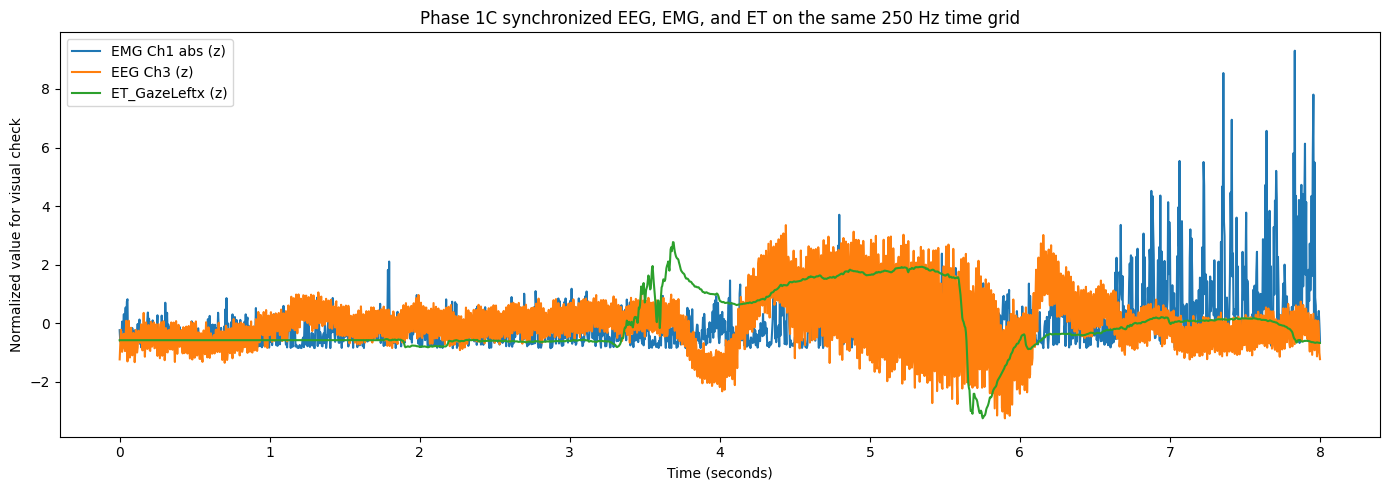

This plot is only a visual check. The saved CSV is not changed by this cell.
✅ CLEANING APPLIED CORRECTLY — CELL 14 — Synchronized overlay plot generated


In [16]:
# ============================================================
# CELL 14 — Plot synchronized EEG, EMG, and ET on the same time axis
# This cell does not change data. It only visualizes whether signals share the same grid.
# ============================================================

def zscore_for_plot(x):
    x = pd.to_numeric(x, errors='coerce').to_numpy(dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-12)

plot_df = saved_df.copy()
plot_seconds = min(8.0, plot_df['Timestamp_seconds'].iloc[-1] - plot_df['Timestamp_seconds'].iloc[0])
plot_df = plot_df[plot_df['Timestamp_seconds'] <= plot_df['Timestamp_seconds'].iloc[0] + plot_seconds]

t = plot_df['Timestamp_seconds'].to_numpy()

plt.figure(figsize=(14, 5))

if 'Ch1 EMG raw' in plot_df.columns:
    plt.plot(t, zscore_for_plot(np.abs(plot_df['Ch1 EMG raw'])), label='EMG Ch1 abs (z)')

if best_eeg_ch in plot_df.columns:
    plt.plot(t, zscore_for_plot(plot_df[best_eeg_ch]), label=f'EEG {best_eeg_ch} (z)')
elif len(eeg_cols) > 0 and eeg_cols[0] in plot_df.columns:
    plt.plot(t, zscore_for_plot(plot_df[eeg_cols[0]]), label=f'EEG {eeg_cols[0]} (z)')

if 'ET_GazeLeftx' in plot_df.columns:
    plt.plot(t, zscore_for_plot(plot_df['ET_GazeLeftx']), label='ET_GazeLeftx (z)')
elif len(et_cols) > 0 and et_cols[0] in plot_df.columns:
    plt.plot(t, zscore_for_plot(plot_df[et_cols[0]]), label=f'{et_cols[0]} (z)')

plt.title('Phase 1C synchronized EEG, EMG, and ET on the same 250 Hz time grid')
plt.xlabel('Time (seconds)')
plt.ylabel('Normalized value for visual check')
plt.legend()
plt.tight_layout()
plt.show()

print("This plot is only a visual check. The saved CSV is not changed by this cell.")
print_step_result("CELL 14 — Synchronized overlay plot generated", True)


In [17]:
# ============================================================
# CELL 15 — Download the Phase 1C output files from Colab
# This cell downloads the synchronized CSV, JSON lag log, and summary report.
# ============================================================

from google.colab import files

files.download(str(out_csv))
files.download(str(out_json))
files.download(str(out_summary))

print("Download requests created for:")
print(" -", out_csv)
print(" -", out_json)
print(" -", out_summary)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download requests created for:
 - /content/phase1C_synchronized_output/063_T24 (1) (1)_synchronized_corrected.csv
 - /content/phase1C_synchronized_output/063_T24 (1) (1)_synchronized_corrected.json
 - /content/phase1C_synchronized_output/synchronization_summary.csv
